# SQL in Python - Connecting to and retrieving data from PostgreSQL

Previously, you have learned how to connect to a SQL database by using a SQL client such as DBeaver. Apart from connecting to databases, DBeaver also allows you to run SQL queries against the database, create new tables and populate them with data as well as retrieving the data.

Python also allows executing SQL queries and getting the result into a Python object, for example a Pandas data frame. Instead of exporting a .csv file from DBeaver you can directly get the data you need into Python and continue your work. In addition we can reduce the steps by connecting to the database from Python directly, eliminating the need for a separate SQL client.

After you have the data in Python in the required shape you can export the data into a .csv file. This file is for your own reference, please avoid sending .csv files around - database is the point of reference when it comes to data. 

Having a copy of a .csv file (or another format) can speed up your analysis work. Imagine that the query takes 25 minutes to run. If you made some mistakes in your Python code you might need to go back to the original dataset. Instead of having to rerun the SQL query and having to wait you can read in the .csv file you have previously saved on your hard disk into Python and continue with your analysis work. 

**In this notebook you will see 2 ways to connect to SQL-Databases and export the data to a CSV file**


## Creating a connection to a PostgreSQL database with Python

There are 2 python packages that are the "go-to" when it comes to connecting to SQL-Databases: `psycopg2` and `sqlalchemy` 

### Connecting via psycopg2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2



In order to create a connection to our PostgreSQL database we need the following information:

- host = the address of the machine the database is hosted on
- port = the virtual gate number through which communication will be allowed
- database = the name of the database
- user = the name of the user
- password = the password of the user

Because we don't want that the database information is published on github we put it into a `.env` file which is added into the `.gitignore`. 
In these kind of files you can store information that is not supposed to be published.
With the `dotenv` package you can read the `.env` files and get the variables.
(We will share the file with you on Slack!)


In [2]:
import os
from dotenv import load_dotenv

# READ database user password host and port from .env
load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

The function from the psycopg2 package to create a connection is called `connect()`.
`connect()` expects the parameters listed above as input in order to connect to the database.

In [3]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

### Retrieving data from the database with psycopg2

Before we can use our connection to get data, we have to create a cursor. A cursor allows Python code to execute PostgreSQL commmands in a database session.
A cursor has to be created with the `cursor()` method of our connection object conn.

In [4]:
cur = conn.cursor()

Now we can run SQL-Queries with `cur.execute('QUERY')` and then run `cur.fetchall()` to get the data:

In [5]:
cur.execute('SELECT * FROM eda.king_county_house_sales LIMIT 10')
cur.fetchall()

[(datetime.date(2014, 10, 13), 221900.0, 7129300520, 1),
 (datetime.date(2014, 12, 9), 538000.0, 6414100192, 2),
 (datetime.date(2015, 2, 25), 180000.0, 5631500400, 3),
 (datetime.date(2014, 12, 9), 604000.0, 2487200875, 4),
 (datetime.date(2015, 2, 18), 510000.0, 1954400510, 5),
 (datetime.date(2014, 5, 12), 1230000.0, 7237550310, 6),
 (datetime.date(2014, 6, 27), 257500.0, 1321400060, 7),
 (datetime.date(2015, 1, 15), 291850.0, 2008000270, 8),
 (datetime.date(2015, 4, 15), 229500.0, 2414600126, 9),
 (datetime.date(2015, 3, 12), 323000.0, 3793500160, 10)]

With `conn.close()` you can close the connection again.

In [6]:
#close the connection
conn.close()

But we want to work with the data. The easiest way is to import the data into pandas dataframes. We can use `pd.read_sql_query` or `pd.read_sql_table` or for convenience `pd.read_sql`.

This function is a convenience wrapper around read_sql_table and read_sql_query (for backward compatibility). It will delegate to the specific function depending on the provided input. A SQL query will be routed to read_sql_query , while a database table name will be routed to read_sql_table . Note that the delegated function might have more specific notes about their functionality not listed here.

In [7]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [8]:
# import the data into a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_sales LIMIT 10"
df_psycopg = pd.read_sql(query_string, conn)

C:\Users\Mahesh\AppData\Local\Temp\ipykernel_13500\1176423828.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psycopg = pd.read_sql(query_string, conn)


In [9]:
#close the connection
conn.close()

In [10]:
df_psycopg.head()

,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5


In [11]:
#export the data to a csv-file
query_string = "SELECT kchd.*, kchs.date, kchs.price \
	FROM king_county_house_details kchd \
		LEFT JOIN king_county_house_sales kchs \
			ON 	kchd.id = kchs.house_id;"
df_psycopg.to_csv('data/eda.csv',index=False)

### Connecting and retrieving data via SQLAlchemy

`sqlalchemy` works similarly. Here you have to create an engine with the database sting (a link that includes every information we entered in the conn object)

In [12]:
from sqlalchemy import create_engine

# READ database user password host and port from .env
load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

#DB_STRING = os.getenv('DB_STRING')

DB_STRING = f"postgresql://{USER_DB}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
db = create_engine(DB_STRING)



And then you can import that engine with a query into a pandas dataframe.

In [13]:
#import the data to a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_sales"
df_sqlalchemy = pd.read_sql(query_string, db)

In [14]:
df_sqlalchemy.head()

,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5


Because we don't want to run the queries over and over again we can export the data into a .csv file in order to use it in other notebooks as well. 

In [15]:
#export the data to a csv-file
df_sqlalchemy.to_csv('eda.csv',index=False)

In [16]:
#import the data from a csv-file
df_import = pd.read_csv('data/eda.csv')

In [17]:
query_string = "SET SCHEMA 'eda'; \
    SELECT kchd.*, kchs.date, kchs.price \
	FROM king_county_house_details kchd \
		LEFT JOIN king_county_house_sales kchs \
			ON 	kchd.id = kchs.house_id;"
df_sqlalchemy = pd.read_sql(query_string, db)

#export the housing data to a csv-file
df_sqlalchemy.to_csv('data/eda_housing.csv',index=False)

In [18]:
df = df_sqlalchemy.copy()
print(df.columns)
df[df["price"]>20000]

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='object')


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0


In [ ]:
df.columns
numeric_df = df.select_dtypes(include=['number'])
print(f"Min year build {numeric_df.yr_built.min()}")
print(f"Min year renovated {numeric_df.yr_renovated.min()}")
numeric_df.head()
numeric_headers = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 
       'sqft_living15', 'sqft_lot15', 'price']
# non_numeric  = ['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
#        'waterfront', 'view', 'condition', 'grade', 'sqft_above',
#        'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
#        'sqft_living15', 'sqft_lot15', 'price']]
print(numeric_df[numeric_df.yr_renovated>0]['yr_renovated'][0:20])
print(df[df.yr_renovated>0]['yr_renovated'][0:20])

Min year build 1900
Min year renovated 0.0
1      19910.0
35     20020.0
95     19910.0
103    20100.0
125    19920.0
158    20130.0
209    19940.0
216    19910.0
230    19780.0
237    20050.0
274    20030.0
282    19940.0
324    19840.0
325    19840.0
330    20020.0
358    19540.0
379    20140.0
398    20110.0
435    20140.0
470    19830.0
Name: yr_renovated, dtype: float64


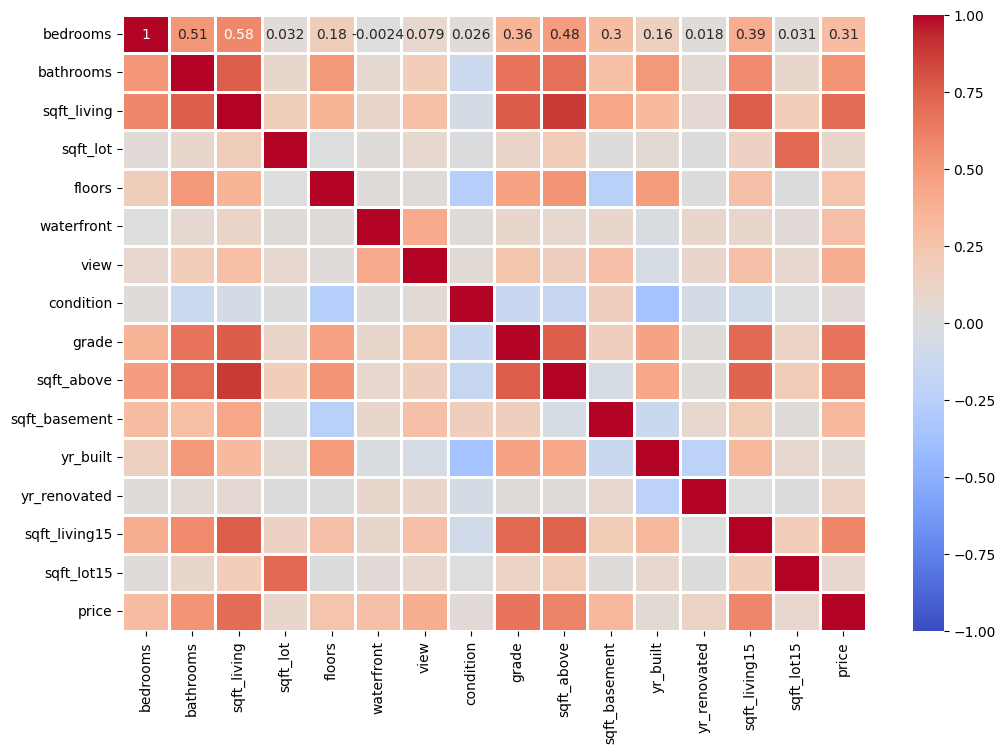

In [20]:
plt.figure(figsize=(12,8),dpi=100)
sns.heatmap(
    data=df[numeric_headers].corr(),
    cmap='coolwarm',
    linecolor='white',
    linewidth=1,
    annot=True,
    vmin=-1,
    vmax=1
);

c:\Users\Mahesh\Spiced\water_ml_ops\eda-project\.venv\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


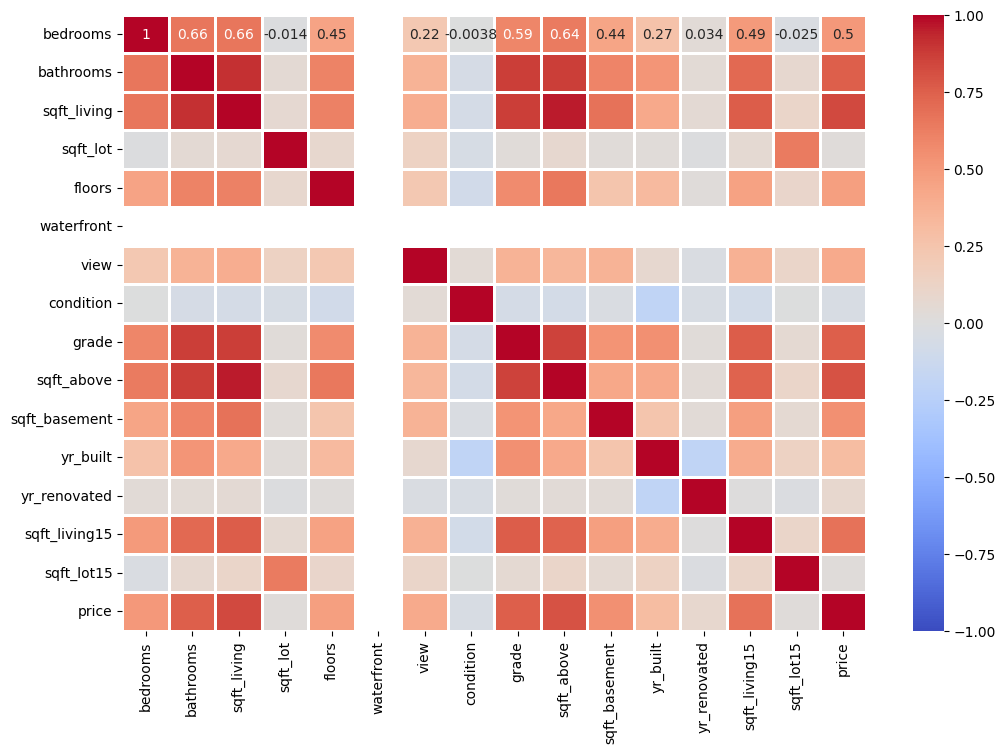

In [21]:
# Filter for Jacob Phillip's preferences
# Assumptions:
# - 'sqft_lot' > 15000 is considered big (enough for tennis court & pool)
# - 'bathrooms' >= 4 for 4+ bathrooms
# - 'waterfront' == 0 for no waterfront
# - 'sqft_living' < 2000 for "smaller house nearby" (adjust as needed)
# - 'golf' and 'historic' columns/tags are not present, so these are not filtered

filtered = df[
    ((df['bathrooms'] >= 4) | (df['sqft_living'] < 2000)) &
    (df['sqft_lot'] > 15000) &
    (df['waterfront'] == 0)
]
# print(f"Total results meeting the client req: {filtered.values()}")
# Show the top results
filtered.head(10)
plt.figure(figsize=(12,8),dpi=100)
sns.heatmap(
    data=filtered[numeric_headers].corr(),
    cmap='coolwarm',
    linecolor='white',
    linewidth=1,
    annot=True,
    vmin=-1,
    vmax=1
);

Spearman correlation between price and grade: 0.66


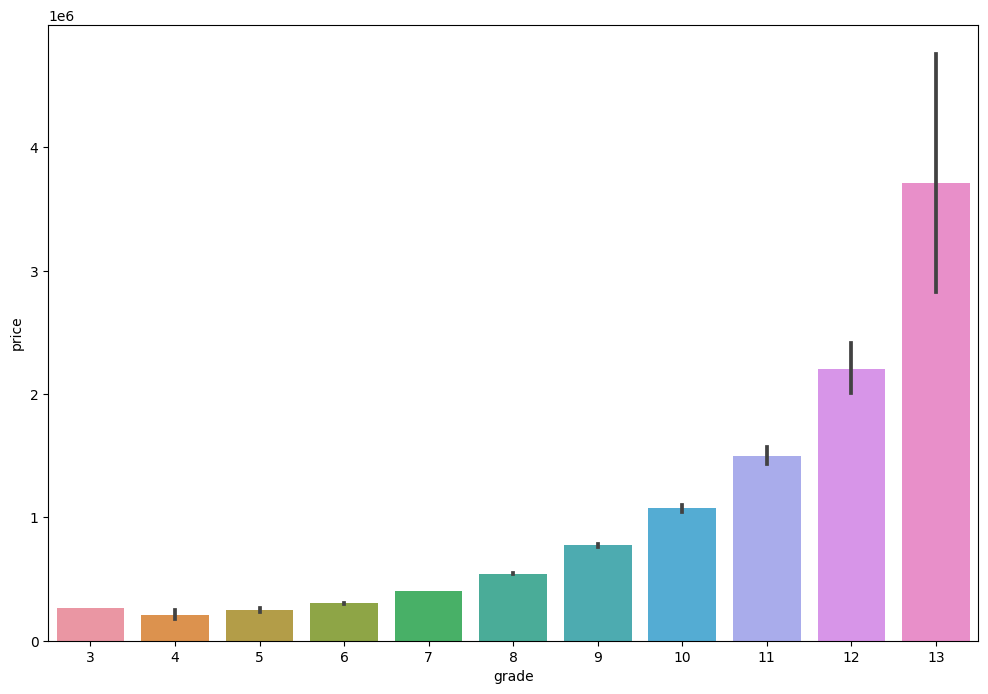

In [71]:
plt.figure(figsize=(12,8),dpi=100)
sns.barplot(
        x=df.grade,
        y=df.price
    );
# Calculate Spearman correlation
spearman_corr = df['price'].corr(df['grade'], method='spearman')
print(f"Spearman correlation between price and grade: {spearman_corr:.2f}")

In [104]:
# Hypothesis: Condition/Grade vs Price  i.e. Houses with better condition or grade have higher prices.
              
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Correlation between grade and price
corr_grade, p_grade = spearmanr(df['grade'], df['price'])
print(f"Spearman correlation between grade and price: {corr_grade:.2f} (p={p_grade:.3g})")

# Correlation between condition and price
corr_cond, p_cond = spearmanr(df['condition'], df['price'])
print(f"Spearman correlation between condition and price: {corr_cond:.2f} (p={p_cond:.3g})")

# Simple linear regression
slope, intercept, r_value, p_value, std_err = linregress(df['grade'], df['price'])
print(f"Linear regression: price = {intercept:.2f} + {slope:.2f} * sqft_living")
print(f"R-squared: {r_value**2:.2f}")




Spearman correlation between grade and price: 0.66 (p=0)
Spearman correlation between condition and price: 0.02 (p=0.00818)
Linear regression: price = -1061415.99 + 209157.78 * sqft_living
R-squared: 0.45


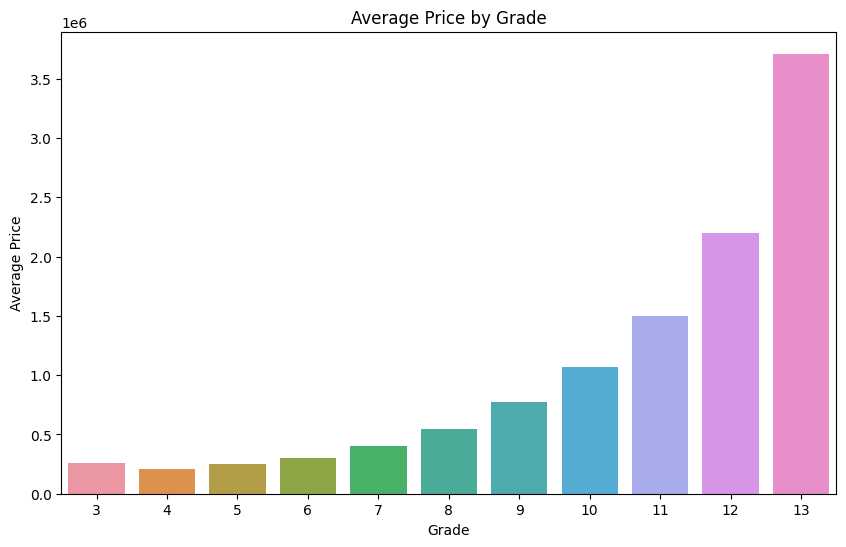

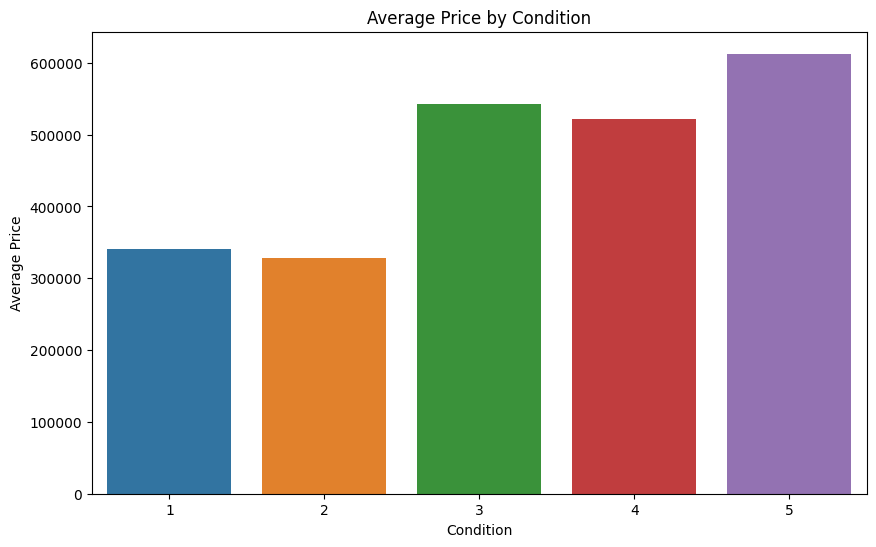

In [103]:
# Plot price vs grade
plt.figure(figsize=(10,6))
sns.barplot(x='grade', y='price', data=df, errorbar=None)
plt.title('Average Price by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Price')
plt.show()

# Plot price vs condition
plt.figure(figsize=(10,6))
sns.barplot(x='condition', y='price', data=df, errorbar=None)
plt.title('Average Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price')
plt.show()

In [108]:
# Hypothesis: As area (sqft_living) increases, price increases

from scipy.stats import spearmanr, linregress, pearsonr
import matplotlib.pyplot as plt

# Calculate Spearman correlation
corr, p_value = spearmanr(df['sqft_living'], df['price'])
print(f"Spearman correlation between sqft_living and price: {corr:.2f} (p={p_value:.3g})")

corr, p_value = pearsonr(df['sqft_living'], df['price'])
print(f"Pearson correlation between sqft_living and price: {corr:.2f} (p={p_value:.3g})")

# Simple linear regression
slope, intercept, r_value, p_val, std_err = linregress(df['sqft_living'], df['price'])
print(f"Linear regression: price = {intercept:.2f} + {slope:.2f} * sqft_living")
print(f"R-squared: {r_value**2:.2f}")

if slope>0 and corr >0 :
    print("!! Attention !! \n A positive Spearman correlation and a positive regression slope both support the hypothesis that as living area increases, price increases.")



Spearman correlation between sqft_living and price: 0.64 (p=0)
Pearson correlation between sqft_living and price: 0.70 (p=0)
Linear regression: price = -43988.89 + 280.86 * sqft_living
R-squared: 0.49
!! Attention !! 
 A positive Spearman correlation and a positive regression slope both support the hypothesis that as living area increases, price increases.


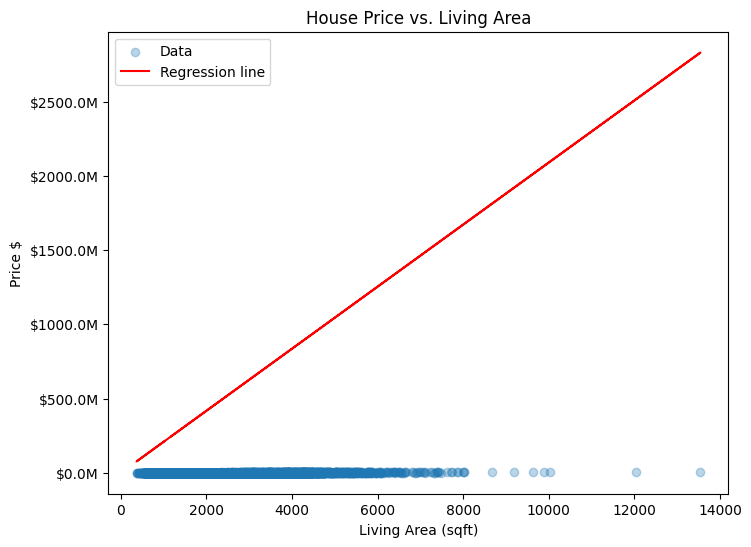

In [ ]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(7,4))
# Format y-axis to show price in millions
formatter = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(7, 4))
plt.scatter(df['sqft_living'], df['price'], alpha=0.3, label='Data')
plt.plot(df['sqft_living'], intercept + slope*df['sqft_living'], color='red', label='Regression line')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price $')
plt.title('House Price vs. Living Area')
plt.legend()

# Format y-axis to show price in millions
formatter = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

In [76]:
df = df_sqlalchemy.copy()

##Create a copy of original data
## Correct the year of renovation currently it has been multiplied by 10.
df['yr_renovated'] = df['yr_renovated'] // 10


In [77]:

#define age of building. Age is define wrt current year i.e. 2025 - year of max(renovation , built).
df['age'] = 2025.0 - df[['yr_renovated', 'yr_built']].max(axis=1)
df.age.head(10)

0    70.0
1    34.0
2    92.0
3    60.0
4    38.0
5    24.0
6    30.0
7    62.0
8    65.0
9    22.0
Name: age, dtype: float64

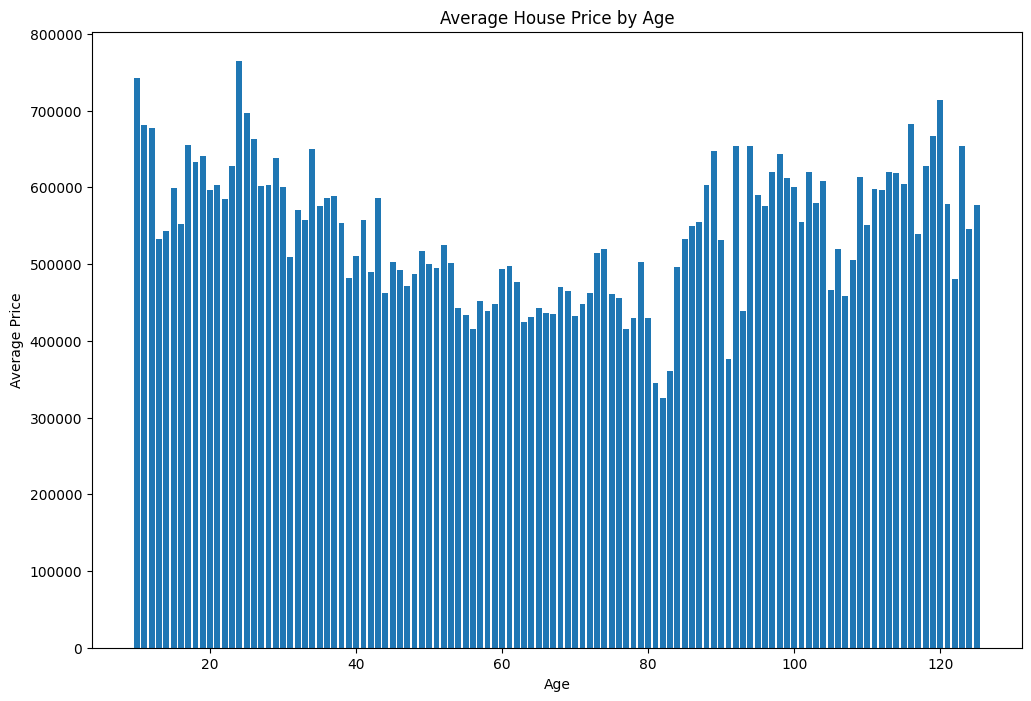

In [ ]:
avg_price = df.groupby('age')['price'].mean().reset_index()
plt.figure(figsize=(12,8),dpi=100)
plt.bar(avg_price['age'], avg_price['price'])
plt.xlabel('Age')
plt.ylabel('Average Price')
plt.title('Average House Price by Age')
plt.show()



In [100]:
from scipy.stats import spearmanr, linregress
from matplotlib.ticker import FuncFormatter

# Calculate Spearman correlation
corr, p_value = spearmanr(df['age'], df['price'])
print(f"Spearman correlation between age and price: {corr:.2f} (p={p_value:.3g})")

# Simple linear regression
slope, intercept, r_value, p_val, std_err = linregress(df['age'], df['price'])
print(f"Linear regression: price = {intercept:.2f} + {slope:.2f} * age")
print(f"R-squared: {r_value**2:.2f}")

if corr<0 and slope<0:
    print("ATTENTION !!! \nA negative Spearman correlation and a negative regression slope both support the hypothesis that as age increases, price decreases.")



Spearman correlation between age and price: -0.15 (p=6.9e-102)
Linear regression: price = 604738.69 + -1237.97 * age
R-squared: 0.01
ATTENTION !!! 
A negative Spearman correlation and a negative regression slope both support the hypothesis that as age increases, price decreases.


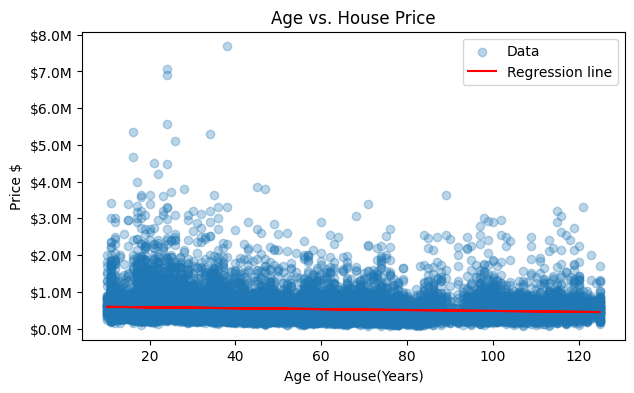

In [ ]:
# Plot Age vs Housing Price.
plt.figure(figsize=(7,4))
plt.scatter(df['age'], df['price'], alpha=0.3, label='Data')
plt.plot(df['age'], intercept + slope*df['age'], color='red', label='Regression line')
plt.xlabel('Age of House(Years)')
plt.ylabel('Price $')
plt.title('Age vs. House Price')
plt.legend()

# Format y-axis to show price in millions
formatter = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

In [23]:
# data visualization stack
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')

# statistics stack
from scipy import stats

# machine learning stack
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score




In [24]:
# data analysis stack
import numpy as np
import pandas as pd

# statistics stack
from scipy import stats

# miscellaneous
import warnings
warnings.simplefilter('ignore')

In [ ]:
# Plot the locations of suitable houses
plt.figure(figsize=(10, 8))
plt.scatter(filtered['long'], filtered['lat'], c='blue', alpha=0.6, edgecolor='k')
plt.title('Geographical Locations of Suitable Houses')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [ ]:
# Plot houses by geolocation, colored by zipcode
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df, x='long', y='lat', hue='price', palette='tab20', legend='full', s=20)
# plt.title('Houses by Zip Code and Geolocation')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='price')
# plt.tight_layout()
# # plt.show();

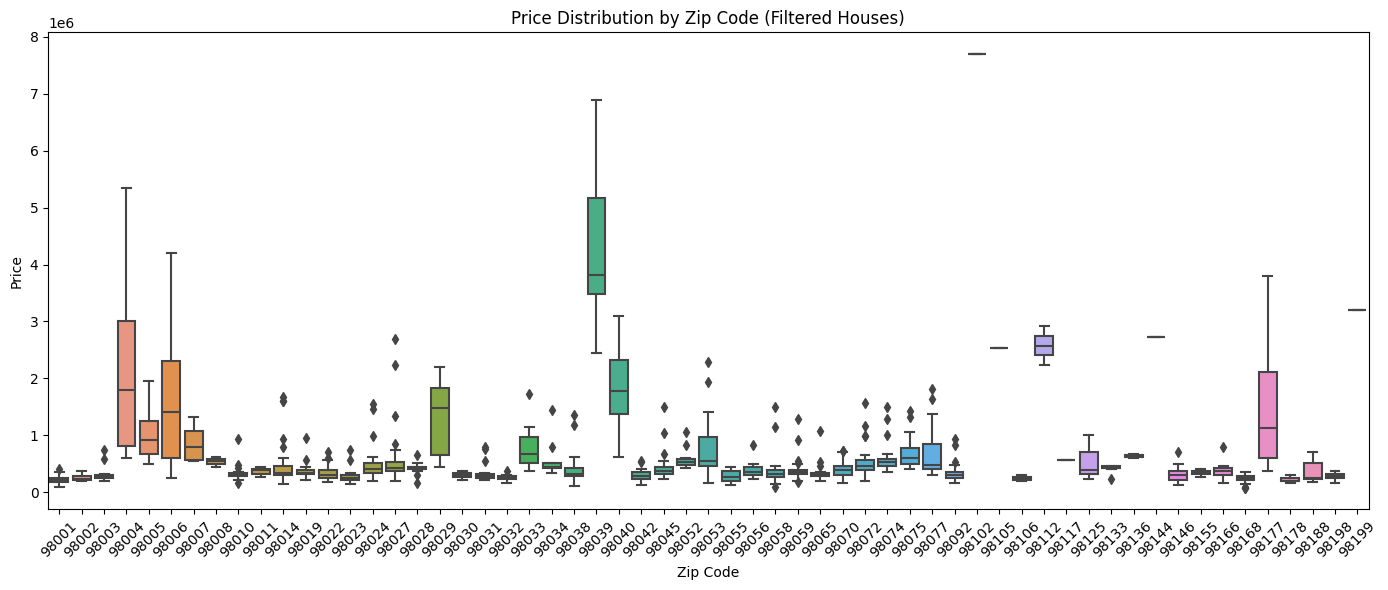

Zip codes with most suitable houses:
zipcode
98001    44
98045    40
98070    40
98042    39
98022    39
Name: count, dtype: int64

Zip codes with lowest median price:
zipcode
98178    195000.0
98001    217500.0
98002    237300.0
98106    240000.0
98032    244750.0
Name: price, dtype: float64


In [84]:
# Plot price vs zip code for filtered houses
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(x='zipcode', y='price', data=filtered)
plt.title('Price Distribution by Zip Code (Filtered Houses)')
plt.xlabel('Zip Code')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find the zip code with the most suitable houses (e.g., most listings or lowest median price)
zip_counts = filtered['zipcode'].value_counts().sort_values(ascending=False)
zip_median_price = filtered.groupby('zipcode')['price'].median().sort_values()

print('Zip codes with most suitable houses:')
print(zip_counts.head())
print('\nZip codes with lowest median price:')
print(zip_median_price.head())